In [1]:
# import modules
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Define lambda functions for path construction
get_data_path = lambda folders, fname: os.path.normpath(os.environ['DRIVE_PATH'] + '/' + '/'.join(folders) + '/' + fname)

# Construct the file paths
file_path_vicky_screen_df = get_data_path(['Sanger', 'Vicky_GI_analysis', 'output'], 'vicky_pairs_SL_annotated.csv')
file_path_expression = get_data_path(['Sanger', 'input_files'], 'OmicsExpressionProteinCodingGenesTPMLogp1.csv')
file_path_vicky_screen_binary_df = get_data_path(['Sanger', 'Vicky_GI_analysis', 'V_Harle_et_al', 'Figures and Tables'], 'Supplementary_Table_5(binary).tsv')

# Outputs
figure_folder = ['Sanger', 'Vicky_GI_analysis', 'figures']

### Read files

In [3]:
vicky_screen_binary = pd.read_csv(file_path_vicky_screen_binary_df, sep="\t")
vicky_screen_binary['sorted_gene_pair'] = vicky_screen_binary['sorted_gene_pair'].str.replace('|', '_', regex=False)
vicky_screen_binary['sorted_gene_pair'] = vicky_screen_binary['sorted_gene_pair'].astype(str).str.strip()

In [4]:
vicky_screen_binary_df = vicky_screen_binary[vicky_screen_binary.columns[:28]]
vicky_screen_binary_df[:3]

,sorted_gene_pair,A-375,A2058,A549,AsPC-1,BxPC-3,C092,Capan-1,CFPAC-1,CHL-1,...,MIA PaCa-2,NCI-H1299,NCI-H1568,NCI-H1975,NCI-H23,SK-MEL-2,SK-MEL-28,SK-MEL-5,SK-MES-1,SU.86.86
0,ABCC3_ATP5PB,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ABL1_ABL2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ABT1_LGALS9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
vicky_screen_binary_df['sum'] = vicky_screen_binary_df.sum(axis=1)
vicky_screen_binary_df = vicky_screen_binary_df.sort_values(by='sum', ascending=False).reset_index(drop=True)

hit_vicky_screen_binary_df = vicky_screen_binary_df.loc[vicky_screen_binary_df['sum'] >= 1,]
hit_vicky_screen_binary_df = hit_vicky_screen_binary_df[['sorted_gene_pair', 'sum']]
print(hit_vicky_screen_binary_df.shape[0])
hit_vicky_screen_binary_df.head()

117


/var/folders/_7/ggc6433j3ys1v8n2lw0hl42r0000gn/T/ipykernel_30382/3259983054.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  vicky_screen_binary_df['sum'] = vicky_screen_binary_df.sum(axis=1)
/var/folders/_7/ggc6433j3ys1v8n2lw0hl42r0000gn/T/ipykernel_30382/3259983054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vicky_screen_binary_df['sum'] = vicky_screen_binary_df.sum(axis=1)


,sorted_gene_pair,sum
0,SEC23A_SEC23B,25
1,CNOT7_CNOT8,25
2,SAR1A_SAR1B,25
3,GDI1_GDI2,25
4,SLC25A28_SLC25A37,24


In [6]:
# read vicky's screen - processed data
vicky_screen_annotated = pd.read_csv(file_path_vicky_screen_df)
vicky_screen_annotated[:2]

,sorted_gene_pair,genepair,A1,A2,A1_entrez,A2_entrez,sgrna_group.x,cell_line_label,CCLEName,DepMap_ID,...,SL,dual_lfc,A1_lfc,A2_lfc,A1_expr,A2_expr,A1_ess,A2_ess,A1_org,A2_org
0,ABCC3_ATP5PB,ABCC3_ATP5PB,ABCC3,ATP5PB,8714,515,CRISPR RNA,A-375,A375_SKIN,ACH-000219,...,False,-0.603633,-0.133793,-0.455638,2.508429,7.493935,0.029750,-0.790555,ABCC3,ATP5PB
1,ABCC3_ATP5PB,ABCC3_ATP5PB,ABCC3,ATP5PB,8714,515,CRISPR RNA,A2058,A2058_SKIN,ACH-000788,...,False,-0.598072,-0.092827,-0.478844,3.737687,7.522464,-0.024834,-0.386851,ABCC3,ATP5PB


In [7]:
vicky_screen_df = vicky_screen_annotated.loc[vicky_screen_annotated['sorted_gene_pair'].isin(hit_vicky_screen_binary_df['sorted_gene_pair']),]
vicky_screen_df = vicky_screen_df.reset_index(drop=True)

In [9]:
print(f"# of unique gene pairs:{vicky_screen_df['genepair'].nunique()}")
display(vicky_screen_df.head())

# of unique gene pairs:117


,sorted_gene_pair,genepair,A1,A2,A1_entrez,A2_entrez,sgrna_group.x,cell_line_label,CCLEName,DepMap_ID,...,SL,dual_lfc,A1_lfc,A2_lfc,A1_expr,A2_expr,A1_ess,A2_ess,A1_org,A2_org
0,ADSS_ADSSL1,ADSS1_ADSS2,ADSS2,ADSS1,159,122622,Paralogue,A-375,A375_SKIN,ACH-000219,...,False,-0.761828,-0.807163,-0.118624,5.961855,1.395063,-0.813350,-0.003197,ADSS,ADSSL1
1,ADSS_ADSSL1,ADSS1_ADSS2,ADSS2,ADSS1,159,122622,Paralogue,A2058,A2058_SKIN,ACH-000788,...,False,-0.450726,-0.224416,-0.184540,5.961855,3.249445,-0.281824,-0.116321,ADSS,ADSSL1
2,ADSS_ADSSL1,ADSS1_ADSS2,ADSS2,ADSS1,159,122622,Paralogue,A549,A549_LUNG,ACH-000681,...,False,-0.649446,-0.264579,-0.416685,5.647315,1.490570,-0.447493,-0.121797,ADSS,ADSSL1
3,ADSS_ADSSL1,ADSS1_ADSS2,ADSS2,ADSS1,159,122622,Paralogue,AsPC-1,ASPC1_PANCREAS,ACH-000222,...,False,-0.966812,-0.897599,-0.091303,6.091700,1.827819,-1.491338,0.079041,ADSS,ADSSL1
4,ADSS_ADSSL1,ADSS1_ADSS2,ADSS2,ADSS1,159,122622,Paralogue,BxPC-3,BXPC3_PANCREAS,ACH-000535,...,False,-0.517603,-0.274559,-0.155135,5.249445,1.361768,-0.255470,-0.038797,ADSS,ADSSL1


In [10]:
depmap_expression = pd.read_csv(file_path_expression, index_col=0)

In [11]:
get_entrez_id = lambda x : re.search(r'\((.*?)\)', x).group(1) #regex to fetch the entrez_id in the column
depmap_expression = depmap_expression.rename(columns=get_entrez_id)
print('Number of genes:', depmap_expression.shape[1], ', num of cell lines:', depmap_expression.shape[0])
depmap_expression[:3]

Number of genes: 19193 , num of cell lines: 1479


,7105,64102,8813,57147,55732,2268,3075,2519,2729,4800,...,8358,8352,8916,115253422,100533105,728929,2831,100506888,162699,1038
ACH-001113,4.331992,0.000000,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,4.739848,...,2.689299,0.189034,0.201634,2.130931,0.555816,0.0,0.275007,0.0,0.0,0.000000
ACH-001289,4.567424,0.584963,7.106641,2.543496,3.504620,0.000000,0.189034,3.813525,4.221877,3.481557,...,1.286881,1.049631,0.321928,1.464668,0.632268,0.0,0.014355,0.0,0.0,0.000000
ACH-001339,3.150560,0.000000,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,3.273516,...,0.594549,1.097611,0.831877,2.946731,0.475085,0.0,0.084064,0.0,0.0,0.042644


In [12]:
# search for duplicates in the depmap_expression columns
search_duplicates = depmap_expression.columns.values.astype(int)
search_duplicates = np.sort(search_duplicates)

unique_values, counts = np.unique(search_duplicates, return_counts=True)
unique_values, counts

duplicates = unique_values[counts > 1]
duplicates

array([   883,   1124,   1394,   6013,   8622,   8916,  10535,  11046,
        29970,  54816,  55486, 220074, 221468, 255027, 284391, 440519,
       552900])

In [14]:
# check if the duplicates are in the vicky_screen
duplicates_str = [str(x) for x in duplicates]
vicky_screen_df.loc[vicky_screen_df['A1_entrez'].isin(duplicates_str) | vicky_screen_df['A2_entrez'].isin(duplicates_str)]

,sorted_gene_pair,genepair,A1,A2,A1_entrez,A2_entrez,sgrna_group.x,cell_line_label,CCLEName,DepMap_ID,...,SL,dual_lfc,A1_lfc,A2_lfc,A1_expr,A2_expr,A1_ess,A2_ess,A1_org,A2_org


In [15]:
depmap_expression_df = depmap_expression.reset_index()
depmap_expression_df = depmap_expression_df.rename(columns = {'index':'DepMap_ID'})
print('num of cell lines with gene expression:', depmap_expression_df.shape[0])

depmap_expression_df_melt = pd.melt(depmap_expression_df, 
                                        id_vars=["DepMap_ID"], 
                                        value_vars=depmap_expression_df.columns,
                                        var_name='entrez_id', value_name='value')

num of cell lines with gene expression: 1479


In [16]:
vicky_screen_genes = set(vicky_screen_df['A1_entrez'].astype(str)).union(set(vicky_screen_df['A2_entrez'].astype(str)))
depmap_expression_subset_melt = depmap_expression_df_melt.loc[depmap_expression_df_melt['entrez_id'].isin(vicky_screen_genes),].reset_index(drop=True)
depmap_expression_subset_melt['entrez_id'] = depmap_expression_subset_melt['entrez_id'].astype(int)
depmap_expression_subset_melt[:3]

,DepMap_ID,entrez_id,value
0,ACH-001113,2288,6.632850
1,ACH-001289,2288,6.336462
2,ACH-001339,2288,5.364222


### Draw Heatmaps

### mRNA range set based on 1st and 3rd percentile of gene expression value across all cell lines for the pair of interest

In [17]:
symbol_to_id = dict(zip(vicky_screen_df['A1'], vicky_screen_df['A1_entrez']))
symbol_to_id.update(dict(zip(vicky_screen_df['A2'], vicky_screen_df['A2_entrez'])))

In [18]:
cols = ['cell_line_label', 'mean_norm_gi', 'A1_lfc', 'A2_lfc', 'dual_lfc', 'A1_expr', 'A2_expr']

In [32]:
def draw_heatmap_quantile(df, cols, pair):
    
    pair_df = df.loc[df['sorted_gene_pair'] == pair, cols]
    clean_pair_df = pair_df.dropna(axis=0, how='any', subset=cols)
    clean_pair_df.loc[:, 'cell_line_label'] = clean_pair_df['cell_line_label'].astype('str')
    clean_pair_df = clean_pair_df.set_index('cell_line_label')

    # sort the DataFrame by the mean_norm_gi
    clean_pair_df = clean_pair_df.sort_values(by='mean_norm_gi', ascending=True)
    #display(clean_pair_df)

    # split the pair
    A1, A2 = pair.split('_')

    #dict
    symbol_to_id = dict(zip(df['A1'], df['A1_entrez']))
    symbol_to_id.update(dict(zip(df['A2'], df['A2_entrez'])))

    exp_df = depmap_expression_subset_melt.loc[depmap_expression_subset_melt['entrez_id'].isin([symbol_to_id[A1], symbol_to_id[A2]]),'value']
    min_exp, max_exp = np.percentile(exp_df, 25), np.percentile(exp_df, 75)

    # find the min and max lfc values
    min_value = round(pd.concat([clean_pair_df['A1_lfc'], clean_pair_df['A2_lfc'], clean_pair_df['dual_lfc']]).min(), 2)
    max_value = round(pd.concat([clean_pair_df['A1_lfc'], clean_pair_df['A2_lfc'], clean_pair_df['dual_lfc']]).max(), 2)
    min_value_ax1 = min_exp
    max_value_ax1 = max_exp
    min_value_ax2 = round(clean_pair_df['mean_norm_gi'].min(), 2)
    max_value_ax2 = round(clean_pair_df['mean_norm_gi'].max(), 2)
    
    colors = ['#d3d3d3', '#EBA8A8', '#dc6767', '#d23b3b']  # Define colors for each class
    my_cmap = LinearSegmentedColormap.from_list("custom_colormap", colors)

    # Define custom colormap for GI heatmap
    gi_cmap = LinearSegmentedColormap.from_list('gi_colormap', ['#88419d', '#f7fcfd'])

    sns.set_context('paper')
    f, ax = plt.subplots(1, 3, figsize=(3.85, 5.5), gridspec_kw={'height_ratios': [1], 'width_ratios': [1, 0.75, 0.55], 'wspace': 0.05})
    
    sns.heatmap(clean_pair_df.loc[:,['A1_lfc', 'A2_lfc', 'dual_lfc']].rename(columns={'A1_lfc':A1, 'A2_lfc':A2, 'dual_lfc':pair}), 
                cmap='PuBu_r', 
                ax=ax[0], 
                cbar_kws={"aspect":6, "orientation": "horizontal", "pad":0.02, "shrink": 0.5},
                vmin=min_value, vmax=max_value, 
                center = (max_value + min_value) / 2, 
                linewidths=0.1, linecolor='black', square=True)
    ax[0].collections[0].colorbar.set_ticks([min_value, max_value])
    ax[0].collections[0].colorbar.set_ticklabels([f'{min_value}', f'{max_value}'])
    ax[0].collections[0].colorbar.ax.tick_params(labelsize=7, length=0)
    ax[0].collections[0].colorbar.ax.set_xlabel('LFC', fontsize=8, labelpad=2.5)

    sns.heatmap(clean_pair_df.loc[:,['A1_expr', 'A2_expr']].rename(columns={'A1_expr':A1, 'A2_expr':A2}),
                cmap=my_cmap, 
                ax=ax[1],
                cbar_kws={"aspect":5, "orientation":"horizontal", "pad":0.02, "shrink": 0.5},
                vmin=min_value_ax1, vmax=max_value_ax1,
                center = (min_value_ax1 + max_value_ax1) / 2,
                linewidths=0.1, linecolor='black', square=True)
    ax[1].collections[0].colorbar.set_ticks([min_value_ax1, max_value_ax1])
    ax[1].collections[0].colorbar.set_ticklabels(['Lo', 'Hi'])
    ax[1].collections[0].colorbar.ax.tick_params(labelsize=7, length=0)
    ax[1].collections[0].colorbar.ax.set_xlabel('mRNA', fontsize=8, labelpad=2.5)

    sns.heatmap(clean_pair_df.loc[:,['mean_norm_gi']],
                cmap=gi_cmap, 
                ax=ax[2],
                cbar_kws={"aspect":5, "orientation":"horizontal", "pad":0.02, "shrink": 0.5},
                vmin=min_value_ax2, vmax=max_value_ax2,
                center = (min_value_ax2 + max_value_ax2) / 2,
                linewidths=0.1, linecolor='black', square=True)
    ax[2].collections[0].colorbar.set_ticks([min_value_ax2, max_value_ax2])
    ax[2].collections[0].colorbar.set_ticklabels([f'{min_value_ax2}', f'{max_value_ax2}'])
    ax[2].collections[0].colorbar.ax.tick_params(labelsize=7, length=0)
    ax[2].collections[0].colorbar.ax.set_xlabel('GI', fontsize=8, labelpad=2.5)

    # Add labels and title
    #ax[0].set_xlabel("LFC", fontsize=7.5)
    ax[0].set_ylabel("")
    ax[0].xaxis.tick_top()
    ax[0].yaxis.tick_left()
    ax[0].tick_params(axis='x', rotation=90, labelsize=7.5, length=0)
    ax[0].tick_params(axis='y', rotation=0, labelsize=7.5, length=0)
    
    #ax[1].set_xlabel("mRNA", fontsize=7.5)
    ax[1].set_ylabel("")
    ax[1].xaxis.tick_top()
    ax[1].set_yticks([])
    ax[1].tick_params(axis='x', rotation=90, labelsize=7.5, length=0)

    ax[2].set_ylabel("")
    ax[2].xaxis.tick_top()
    ax[2].set_yticks([])
    ax[2].set_xticks([])

    #plt.tight_layout(pad=3)
    plt.subplots_adjust(top=0.80, bottom=0.01, left=0.2, right=0.85, hspace=0.05, wspace=0.05)
    #plt.show()
    #plt.savefig(get_data_path(figure_folder, f'/heatmap_lfc_exp_gi/{pair}.png'), dpi=800)
    plt.savefig(get_data_path(figure_folder, f'/heatmap_lfc_exp_gi_v2/{pair}.png'), dpi=800)
    plt.close()


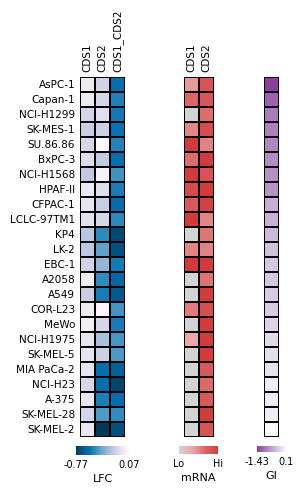

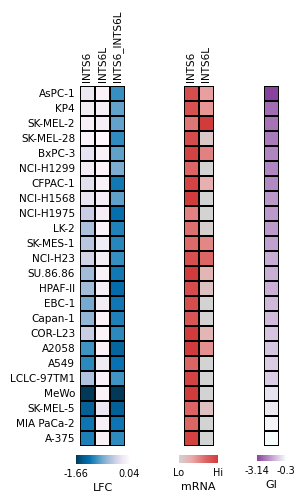

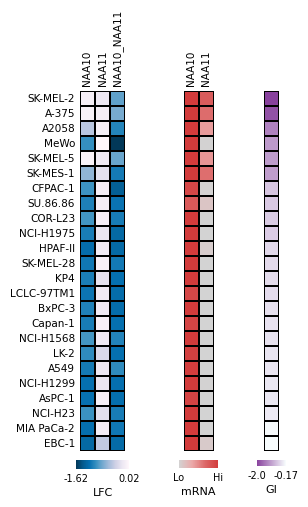

In [22]:
draw_heatmap_quantile(vicky_screen_df, cols, 'CDS1_CDS2')
draw_heatmap_quantile(vicky_screen_df, cols, 'INTS6_INTS6L')
draw_heatmap_quantile(vicky_screen_df, cols, 'NAA10_NAA11')

In [35]:
# plot all paralog pairs
corr_pairs = ['CDS1_CDS2',
 'CLASP1_CLASP2',
 'CTPS1_CTPS2',
 'ELL_ELL2',
 'GIT1_GIT2',
 'INTS6_INTS6L',
 'MAT1A_MAT2A',
 'NAA10_NAA11',
 'NCKAP1_NCKAP1L',
 'NDE1_NDEL1',
 'RBBP4_RBBP7',
 'SEC23A_SEC23B',
 ]

for pair in corr_pairs:
    draw_heatmap_quantile(vicky_screen_df, cols, pair)

/var/folders/_7/ggc6433j3ys1v8n2lw0hl42r0000gn/T/ipykernel_30382/803763043.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_pair_df.loc[:, 'cell_line_label'] = clean_pair_df['cell_line_label'].astype('str')
/var/folders/_7/ggc6433j3ys1v8n2lw0hl42r0000gn/T/ipykernel_30382/803763043.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_pair_df.loc[:, 'cell_line_label'] = clean_pair_df['cell_line_label'].astype('str')
/var/folders/_7/ggc6433j3ys1v8n2lw0hl42r0000gn/T/ipykernel_30382/803763043.py:5: